# Exploratory analysis

This notebook loads the raw iNaturalist export of 9,199 fruit fly (Tephritidae) observations, cleans it by trimming to the relevant columns, parsing dates, flagging taxonomic resolution (species vs genus-level ID), flagging coordinate reliability (not obscured, accurate to within 10km), filling missing host plant values as "Unknown," flagging research-grade vs unconfirmed records, and removing duplicates, then explores the cleaned data through visualizations covering species frequency and identification confidence, temporal and seasonal trends, geographic distribution, and the split between occurrence-only records and host-plant interaction records.

# 01. Load, Explore, and Analyze

Fruit fly (Tephritidae) host plant interactions, iNaturalist citizen science data.

This notebook loads the raw export of 9,199 observations, explores it to understand what needs fixing, then cleans and analyzes it, exporting `clean_data.csv` for use in notebook 02 (host-pest interaction analysis and species distribution modeling).

## Environment

Developed and run in a conda environment with the packages in `requirements.txt` installed.

```bash
conda create -n eneza-project python=3.11 -y
conda activate eneza-project
pip install -r requirements.txt
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

# Part 1: Load
Read the raw data and get a first look: shape, columns, data types, and how much is missing.

In [2]:
raw = pd.read_csv('../data/raw_data.csv', sep='\t', low_memory=False)
print('Shape:', raw.shape)
raw.head()

Shape: (9199, 73)


,id,uuid,observed_on_string,observed_on,time_observed_at,time_zone,user_id,user_login,user_name,created_at,updated_at,quality_grade,license,url,image_url,sound_url,tag_list,description,num_identification_agreements,num_identification_disagreements,captive_cultivated,oauth_application_id,place_guess,latitude,longitude,...,taxon_subphylum_name,taxon_superclass_name,taxon_class_name,taxon_subclass_name,taxon_superorder_name,taxon_order_name,taxon_suborder_name,taxon_superfamily_name,taxon_family_name,taxon_subfamily_name,taxon_supertribe_name,taxon_tribe_name,taxon_subtribe_name,taxon_genus_name,taxon_genushybrid_name,taxon_species_name,taxon_hybrid_name,taxon_subspecies_name,taxon_variety_name,taxon_form_name,host_plant,obs_date,obs_month,obs_year,Data_Category
0,229489,6bb20884-a1a8-4a32-a5c8-2cbed47d5ad6,05/04/2013 08:01,05/04/2013,2013-04-05 02:31:43 +0000,Kolkata,8853,ivijayanand,Vijay Anand Ismavel,2013-04-05 15:58:58 +0000,2017-10-29 02:30:30 +0000,needs_id,CC-BY-NC,http://www.inaturalist.org/observations/229489,https://inaturalist-open-data.s3.amazonaws.com...,NaN,"Makunda Insects, Bactrocera caudata","Location: Makunda Christian Hospital, Karimgan...",2,0,False,NaN,"Makunda Christian Hospital, Karimganj District...",24.432020,92.330689,...,Hexapoda,NaN,Insecta,Pterygota,NaN,Diptera,Brachycera,Tephritoidea,Tephritidae,Dacinae,NaN,Dacini,NaN,Bactrocera,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,05/04/2013,4,2013,Occurrence Only
1,663857,3fca9700-5ad3-4232-93d3-04e460a1f13b,14/10/2011,14/10/2011,NaN,Rome,32921,enricoschifani,Enrico Schifani,2014-05-06 16:50:12 +0000,2021-11-21 09:59:34 +0000,research,NaN,http://www.inaturalist.org/observations/663857,https://static.inaturalist.org/photos/836423/m...,NaN,NaN,NaN,2,0,False,NaN,Mondello,38.195269,13.335471,...,Hexapoda,NaN,Insecta,Pterygota,NaN,Diptera,Brachycera,Tephritoidea,Tephritidae,Dacinae,NaN,Dacini,NaN,Bactrocera,NaN,Bactrocera oleae,NaN,NaN,NaN,NaN,Olea europaea,14/10/2011,10,2011,Interaction Study
2,718148,997499b2-e0c4-4ce4-a15c-ff813133a315,"June 04, 2014 11:13",04/06/2014,2014-06-04 03:13:00 +0000,Singapore,31576,techieoldfox,Jonathan Hiew,2014-06-05 03:15:55 +0000,2026-04-04 07:57:48 +0000,research,CC-BY-NC-SA,http://www.inaturalist.org/observations/718148,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,"Oriental Fruit Fly, Bactrocera dorsalis",2,0,False,NaN,Singapore,1.348855,103.762573,...,Hexapoda,NaN,Insecta,Pterygota,NaN,Diptera,Brachycera,Tephritoidea,Tephritidae,Dacinae,NaN,Dacini,NaN,Bactrocera,NaN,Bactrocera dorsalis,NaN,NaN,NaN,NaN,Unknown,04/06/2014,6,2014,Occurrence Only
3,783490,446949ef-1baa-4e13-98f9-f0b44039a3ee,06/07/2014 10:36,06/07/2014,2014-07-06 02:36:02 +0000,Hong Kong,24661,sunnetchan,Sunnetchan,2014-07-14 06:37:23 +0000,2023-04-14 07:34:59 +0000,research,CC-BY-NC-ND,http://www.inaturalist.org/observations/783490,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,æ±æ–¹æžœå¯¦è … Bactrocera dorsalis\r\n\r\nRef...,1,0,False,NaN,"Sui Lau Tin, Hong Kong",22.430309,114.086419,...,Hexapoda,NaN,Insecta,Pterygota,NaN,Diptera,Brachycera,Tephritoidea,Tephritidae,Dacinae,NaN,Dacini,NaN,Bactrocera,NaN,Bactrocera dorsalis,NaN,NaN,NaN,NaN,Unknown,06/07/2014,7,2014,Occurrence Only
4,791094,068abc8d-e1f1-447b-929d-35c63506c014,12/07/2014,12/07/2014,NaN,Wellington,13200,d_kluza,NaN,2014-07-19 04:18:32 +0000,2024-04-22 03:41:29 +0000,research,CC-BY-NC-ND,http://www.inaturalist.org/observations/791094,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,NaN,2,0,False,NaN,Singapore Botanic Garden,1.317138,103.815919,...,Hexapoda,NaN,Insecta,Pterygota,NaN,Diptera,Brachycera,Tephritoidea,Tephritidae,Dacinae,NaN,Dacini,NaN,Bactrocera,NaN,Bactrocera dorsalis,NaN,NaN,NaN,NaN,Unknown,12/07/2014,7,2014,Occurrence Only


In [3]:
raw.dtypes.value_counts()

object     46
float64    18
int64       7
bool        2
Name: count, dtype: int64

In [4]:
raw.isna().sum().sort_values(ascending=False).head(15)

taxon_superclass_name     9199
taxon_form_name           9199
taxon_subtribe_name       9199
private_longitude         9199
taxon_genushybrid_name    9199
sound_url                 9199
taxon_hybrid_name         9199
private_place_guess       9199
taxon_variety_name        9199
taxon_subspecies_name     9199
taxon_supertribe_name     9199
taxon_superorder_name     9199
private_latitude          9199
taxon_geoprivacy          9196
tag_list                  8990
dtype: int64

# Explore the dataset

In [5]:
#Checking the duplicates 

print('Duplicate ids:', raw['id'].duplicated().sum())
print('Full row duplicates:', raw.duplicated().sum())

Duplicate ids: 0
Full row duplicates: 0


In [6]:
print('Lat range:', raw['latitude'].min(), 'to', raw['latitude'].max())
print('Lon range:', raw['longitude'].min(), 'to', raw['longitude'].max())
print('Missing coordinates:', raw['latitude'].isna().sum())
print('Coordinates obscured:', raw['coordinates_obscured'].sum())
print('Positional accuracy over 10km:', (raw['positional_accuracy'] > 10000).sum())

Lat range: -38.18821333 to 52.58439021
Lon range: -175.2633413 to 169.77946
Missing coordinates: 36
Coordinates obscured: 584
Positional accuracy over 10km: 298


In [7]:
name_word_count = raw['scientific_name'].str.split().str.len()
print('Species-level names (2+ words):', (name_word_count >= 2).sum())
print('Genus-or-higher names (1 word):', (name_word_count == 1).sum())

Species-level names (2+ words): 5807
Genus-or-higher names (1 word): 3392


# Exploratory Analysis 
# Cleaning

In [8]:
KEEP_COLS = [
    'id', 'uuid', 'observed_on', 'obs_year', 'obs_month',
    'quality_grade', 'license',
    'latitude', 'longitude', 'positional_accuracy', 'coordinates_obscured',
    'place_country_name', 'place_state_name', 'place_admin1_name',
    'species_guess', 'scientific_name', 'common_name',
    'taxon_genus_name', 'taxon_species_name',
    'host_plant', 'Data_Category',
    'num_identification_agreements', 'num_identification_disagreements',
    'url', 'image_url',
]

df = raw[KEEP_COLS].copy()
df.shape

(9199, 25)

In [9]:
df['observed_on'] = pd.to_datetime(df['observed_on'], format='%d/%m/%Y', errors='coerce')
before = len(df)
df = df.dropna(subset=['observed_on'])
print(f'Dropped {before - len(df)} rows with unparseable dates')

Dropped 0 rows with unparseable dates


In [10]:
df['name_word_count'] = df['scientific_name'].str.split().str.len()
df['taxon_resolution'] = np.where(df['name_word_count'] >= 2, 'species', 'genus_or_higher')
df = df.drop(columns=['name_word_count'])
df['taxon_resolution'].value_counts()

taxon_resolution
species            5807
genus_or_higher    3392
Name: count, dtype: int64

In [11]:
df['host_plant'] = df['host_plant'].fillna('Unknown')
df['has_host_plant'] = df['host_plant'] != 'Unknown'
df['is_research_grade'] = df['quality_grade'] == 'research'

before = len(df)
df = df.drop_duplicates(subset=['id']).reset_index(drop=True)
print(f'Dropped {before - len(df)} duplicate rows')
df.shape

Dropped 0 duplicate rows


(9199, 28)

# Species frequency

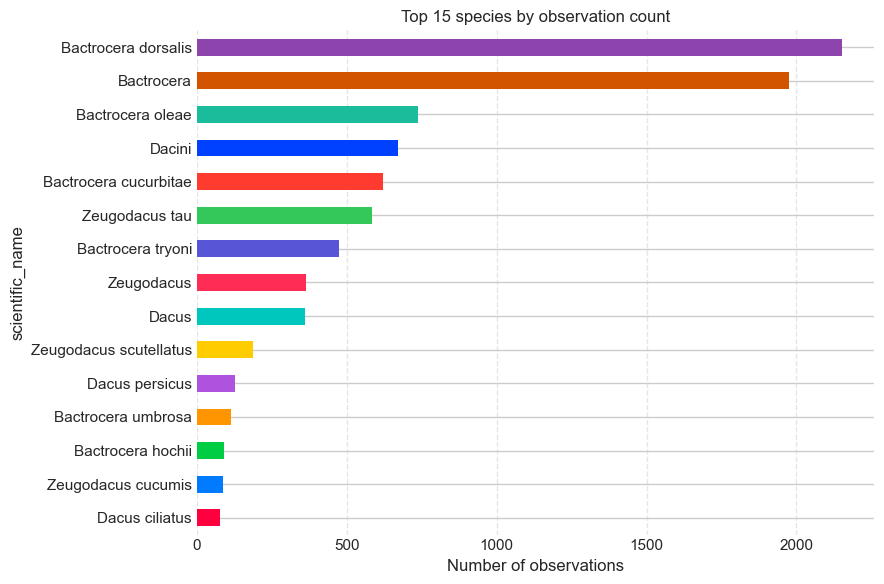

In [12]:
top_species = df['scientific_name'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#FF003F', '#007AFF', '#00CC44', '#FF9500', '#AF52DE', '#FFCC00', '#00C7BE', '#FF2D55', '#5856D6', '#34C759', '#FF3B30', '#0040FF', '#1ABC9C', '#D35400', '#8E44AD']
top_species.sort_values().plot(kind='barh', ax=ax, color=colors[:len(top_species)], edgecolor='none', zorder=3)
ax.set_xlabel('Number of observations')
ax.set_title('Top 15 species by observation count')
ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
for s in ['top', 'right', 'left', 'bottom']: ax.spines[s].set_visible(False)
ax.tick_params(axis='both', which='both', length=0)
plt.tight_layout()
plt.savefig('../outputs/figures/top_species.png', dpi=200, bbox_inches='tight')
plt.show()


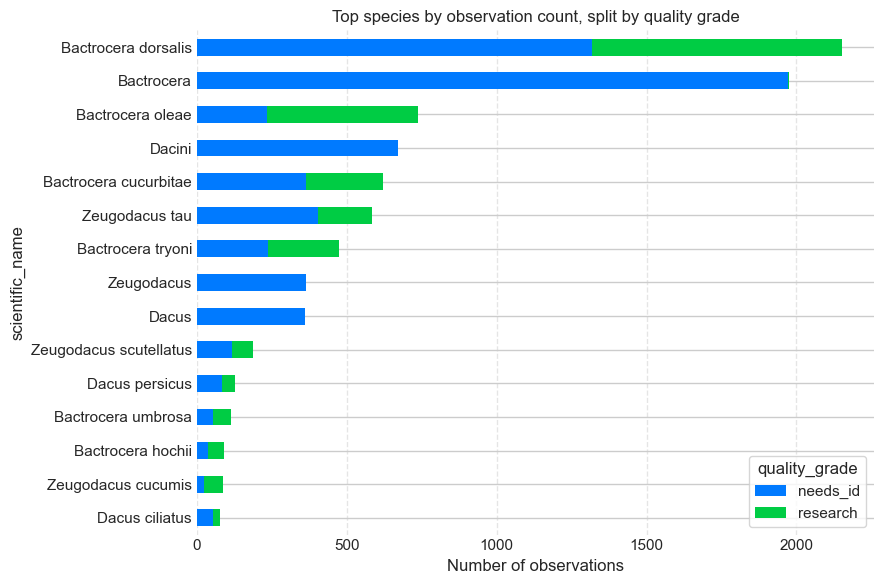

In [13]:
quality_by_species = (
    df[df['scientific_name'].isin(top_species.index)]
    .groupby(['scientific_name', 'quality_grade'])
    .size()
    .unstack(fill_value=0)
)
quality_by_species = quality_by_species.loc[top_species.sort_values().index]
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#007AFF', '#00CC44', '#FF9500', '#FF3B30'] 
quality_by_species.plot(kind='barh', stacked=True, ax=ax, color=colors[:quality_by_species.shape[1]], edgecolor='none', zorder=3)
plt.xlabel('Number of observations')
plt.title('Top species by observation count, split by quality grade')
ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
for s in ['top', 'right', 'left', 'bottom']: ax.spines[s].set_visible(False)
ax.tick_params(axis='both', which='both', length=0)
plt.tight_layout()
plt.savefig('../outputs/figures/species_quality.png', dpi=200, bbox_inches='tight')
plt.show()


# Temporal trends 

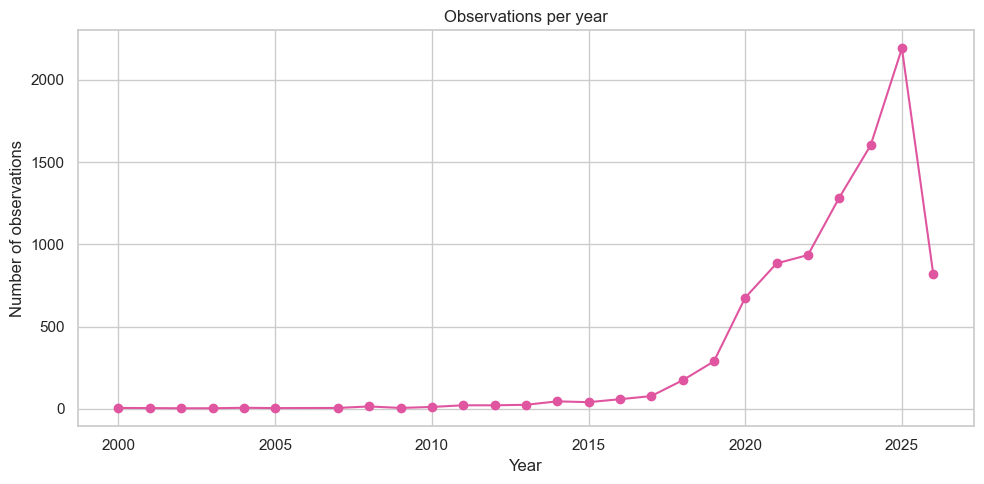

In [14]:
obs_per_year = df['obs_year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
obs_per_year.plot(kind='line', marker='o', ax=ax, color='#e0559f')
ax.set_xlabel('Year')
ax.set_ylabel('Number of observations')
ax.set_title('Observations per year')
plt.tight_layout()
plt.savefig('../outputs/figures/observations_per_year.png', dpi=150)
plt.show()

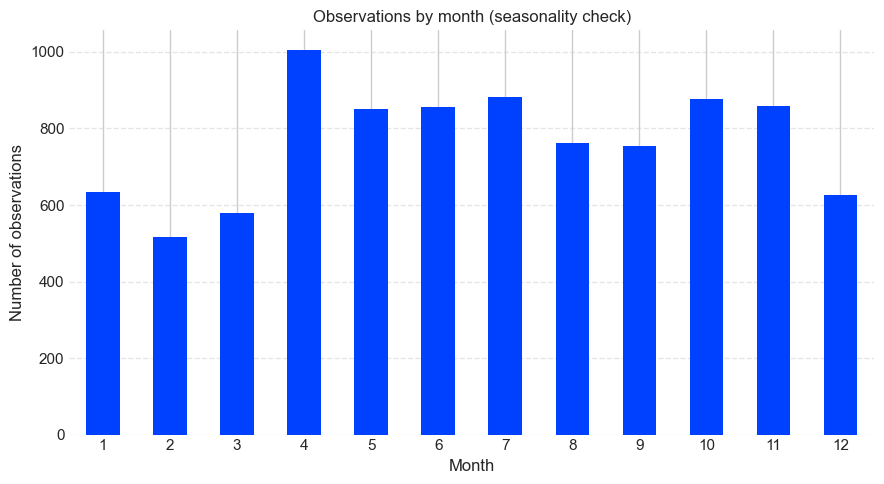

In [15]:
obs_per_month = df['obs_month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
obs_per_month.plot(kind='bar', ax=ax, color='#0040FF', edgecolor='none', zorder=3)
ax.set_xlabel('Month')
ax.set_ylabel('Number of observations')
ax.set_title('Observations by month (seasonality check)')
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
for s in ['top', 'right', 'left', 'bottom']: ax.spines[s].set_visible(False)
ax.tick_params(axis='both', which='both', length=0)
plt.xticks(rotation=0) 
plt.tight_layout()
plt.savefig('../outputs/figures/observations_per_month.png', dpi=200, bbox_inches='tight')
plt.show()


# Geographic Distribution

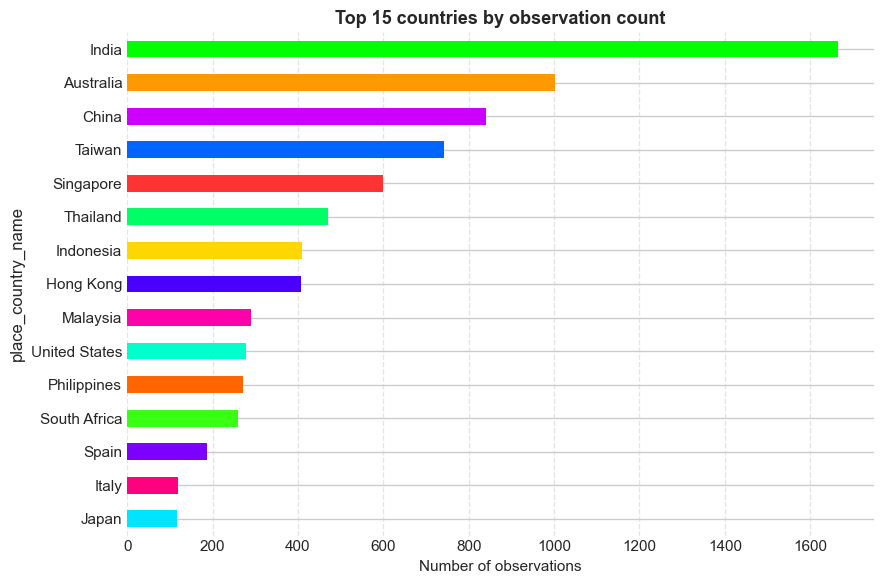

In [16]:
top_countries = df['place_country_name'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#00E5FF', '#FF007F', '#7D00FF', '#39FF14', '#FF6600', '#00FFCC', '#FF00AA', '#4900FF', '#FFD700', '#00FF66', '#FF3333', '#0066FF', '#CC00FF', '#FF9900', '#00FF00']
top_countries.sort_values().plot(kind='barh', ax=ax, color=colors[:len(top_countries)], edgecolor='none', zorder=3)
ax.set_xlabel('Number of observations', fontsize=11)
ax.set_title('Top 15 countries by observation count', fontsize=13, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
for s in ['top', 'right', 'left', 'bottom']: ax.spines[s].set_visible(False)
ax.tick_params(axis='both', which='both', length=0)
plt.tight_layout()
plt.savefig('../outputs/figures/top_countries.png', dpi=200, bbox_inches='tight')
plt.show()


# Host-plants patterns 

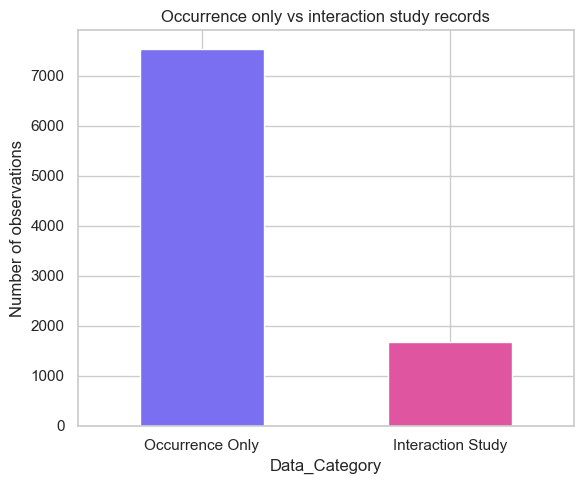

In [17]:
df['Data_Category'].value_counts().plot(kind='bar', color=['#7a6ff0', '#e0559f'], figsize=(6, 5))
plt.ylabel('Number of observations')
plt.title('Occurrence only vs interaction study records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/data_category.png', dpi=150)
plt.show()

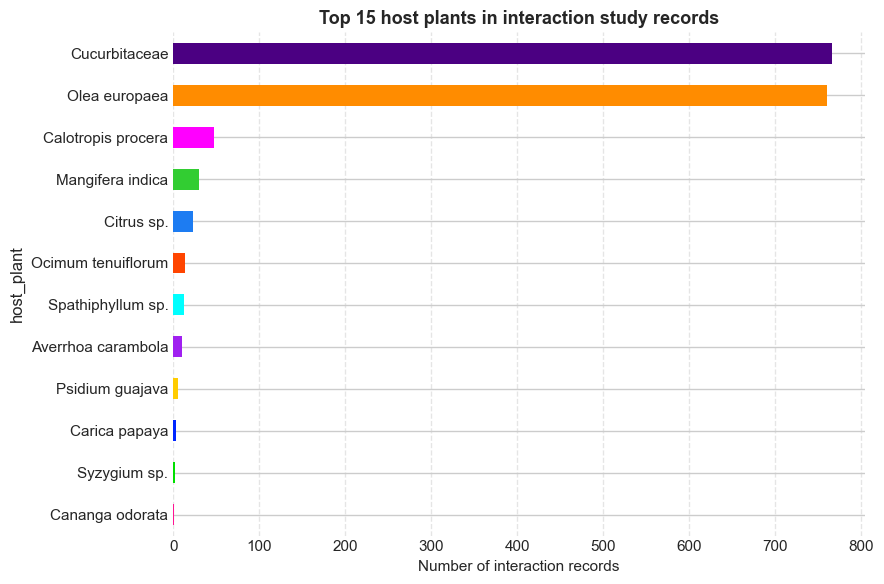

In [18]:
interactions = df[df['Data_Category'] == 'Interaction Study']
top_hosts = interactions['host_plant'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#FF1493', '#00DF00', '#0026FF', '#FFCC00', '#A020F0', '#00FFFF', '#FF4500', '#1D7CF2', '#32CD32', '#FF00FF', '#FF8C00', '#4B0082', '#00FA9A', '#ED1C24', '#795548']
top_hosts.sort_values().plot(kind='barh', ax=ax, color=colors[:len(top_hosts)], edgecolor='none', zorder=3)
ax.set_xlabel('Number of interaction records', fontsize=11)
ax.set_title('Top 15 host plants in interaction study records', fontsize=13, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
for s in ['top', 'right', 'left', 'bottom']: ax.spines[s].set_visible(False)
ax.tick_params(axis='both', which='both', length=0)
plt.tight_layout()
plt.savefig('../outputs/figures/top_host_plants.png', dpi=200, bbox_inches='tight')
plt.show()


In [19]:
df['has_coords'] = df['latitude'].notna() & df['longitude'].notna()
df['coord_reliable'] = (
    df['has_coords']
    & (~df['coordinates_obscured'].fillna(False))
    & (df['positional_accuracy'].fillna(0) <= 10000)
)
df['coord_reliable'].value_counts()

coord_reliable
True     8339
False     860
Name: count, dtype: int64

In [20]:
# Exporting the dataset

df.to_csv('../data/clean_data.csv', index=False)
print(f'Raw rows: {len(raw)}')
print(f'Clean rows: {len(df)}')
print(f'Species-level records: {(df["taxon_resolution"]=="species").sum()}')
if "coord_reliable" in df.columns:
    print(f'Reliable-coordinate records: {df["coord_reliable"].sum()}')
else:
    print('Reliable-coordinate records: Column "coord_reliable" missing')
print(f'Interaction-study records: {(df["Data_Category"]=="Interaction Study").sum()}')


Raw rows: 9199
Clean rows: 9199
Species-level records: 5807
Reliable-coordinate records: 8339
Interaction-study records: 1673


In [21]:
df['observed_on'] = pd.to_datetime(df['observed_on'], format='%d/%m/%Y', errors='coerce')
before = len(df)
df = df.dropna(subset=['observed_on'])
print(f'Dropped {before - len(df)} rows with unparseable dates')

Dropped 0 rows with unparseable dates


In [22]:
print('coord_reliable' in df.columns)
print(df.columns.tolist())

True
['id', 'uuid', 'observed_on', 'obs_year', 'obs_month', 'quality_grade', 'license', 'latitude', 'longitude', 'positional_accuracy', 'coordinates_obscured', 'place_country_name', 'place_state_name', 'place_admin1_name', 'species_guess', 'scientific_name', 'common_name', 'taxon_genus_name', 'taxon_species_name', 'host_plant', 'Data_Category', 'num_identification_agreements', 'num_identification_disagreements', 'url', 'image_url', 'taxon_resolution', 'has_host_plant', 'is_research_grade', 'has_coords', 'coord_reliable']
